# Eksperimen E5: Analisis Kasus Kegagalan (Failure Analysis)

Notebook ini mendemonstrasikan bagaimana kita mengaudit dan membedah kasus-kasus di mana AI (BirdNET/PANNs) **gagal** mengenali suara burung (*False Negatives*).
Fokus utama kita adalah mengklasifikasikan diagnosis kegagalan pada kondisi ekstrem (seperti Derau Kampus ITERA SNR -5 dB).

## Objektif:
1. Memuat tabel audit kegagalan nyata `failure_analysis_table.csv`.
2. Memvisualisasikan distribusi penyebab utama kegagalan (*Primary Cause*).
3. Menelusuri metadata spesifik kueri yang gagal untuk dilaporkan di Bab 4.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import IPython.display as ipd

# 1. Pastikan jalur repository sistem terbaca
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("[+] Pustaka E5 Berhasil Dimuat!")

[+] Pustaka E5 Berhasil Dimuat!


## Tahap 1: Memuat Tabel Audit Kegagalan
Kita akan memuat 30 kasus representatif dari eksperimen retrieval yang mendapatkan nilai `top1_match == 0`.

In [2]:
FAILURE_CSV = PROJECT_ROOT / "results/processed/failure_analysis_table.csv"

if FAILURE_CSV.exists():
    df_fail = pd.read_csv(FAILURE_CSV)
    print(f"[+] Ditemukan {len(df_fail)} kasus kegagalan.")
    display(df_fail.head(10))
else:
    print("[-] Tabel kegagalan belum ada. Jalankan src/analyze_failures.py terlebih dahulu.")

[+] Ditemukan 30 kasus kegagalan.


,case_id,failure_type,representation,query_id,species_key,recordist,condition,similarity_score,threshold_tau,primary_cause,diagnosis_and_threat
0,FAIL_001,False_Negative,R2,XC50033,greant1,Bernabe Lopez-Lanus,SNR_-5dB,0.6237,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
1,FAIL_002,False_Negative,R2,XC616309,greant1,Fabrice Schmitt,SNR_-5dB,0.6369,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
2,FAIL_003,False_Negative,R2,XC118887,greant1,GABRIEL LEITE,SNR_-5dB,0.6666,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
3,FAIL_004,False_Negative,R2,XC549933,squcuc1,Bernabe Lopez-Lanus,SNR_-5dB,0.6690,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
4,FAIL_005,False_Negative,R2,XC372463,roahaw,Kent Livezey,SNR_-5dB,0.6371,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
5,FAIL_006,False_Negative,R2,XC288830,roahaw,Diego Cueva,SNR_-5dB,0.6938,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
6,FAIL_007,False_Negative,R2,XC680705,roahaw,GABRIEL LEITE,SNR_-5dB,0.7152,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
7,FAIL_008,False_Negative,R2,XC235156,roahaw,cesar villamil,SNR_-5dB,0.6639,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
8,FAIL_009,False_Negative,R2,XC19527,roahaw,Niels Krabbe,SNR_-5dB,0.5970,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...
9,FAIL_010,False_Negative,R2,XC447808,trsowl,Kent Livezey,SNR_-5dB,0.7035,0.7062,low_snr_masking,Energi derau aditif pada SNR -5 dB mengaburkan...


## Tahap 2: Visualisasi Distribusi Penyebab Kegagalan
Mengapa mesin bisa salah mengenali kicauan? Biasanya ada dua penyebab dominan di kondisi skripsi kita:
1. **Low SNR Masking:** Kicauan burung tertutup/kalah volume oleh bising kendaraan atau serangga.
2. **Acoustic Feature Overlap:** Kicauan burung sangat mirip dengan burung spesies lain di dalam database.

C:\Users\Fabio\AppData\Local\Temp\ipykernel_16888\2911212935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fail, y='primary_cause', palette='pastel', order=df_fail['primary_cause'].value_counts().index)


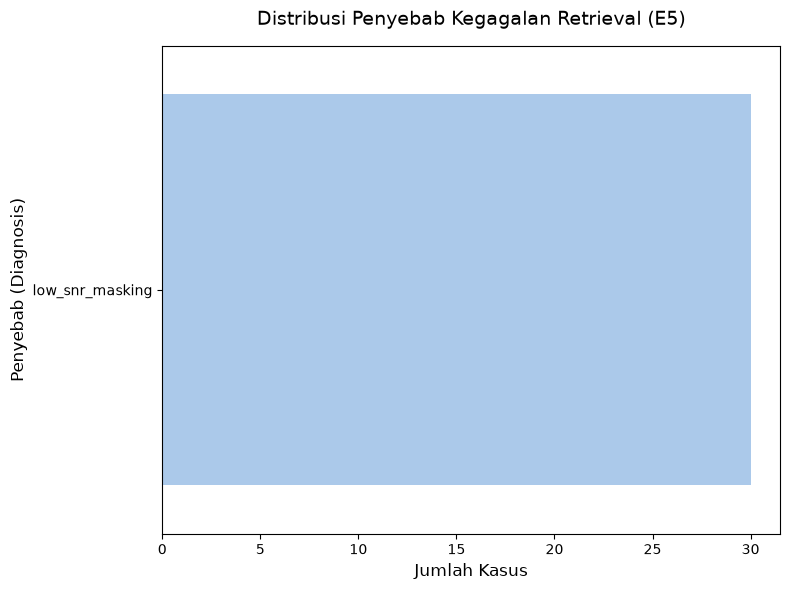


--- Rangkuman Persentase ---
primary_cause
low_snr_masking    100.0 %
Name: proportion, dtype: str


In [3]:
if 'df_fail' in locals():
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_fail, y='primary_cause', palette='pastel', order=df_fail['primary_cause'].value_counts().index)
    
    plt.title("Distribusi Penyebab Kegagalan Retrieval (E5)", fontsize=14, pad=15)
    plt.xlabel("Jumlah Kasus", fontsize=12)
    plt.ylabel("Penyebab (Diagnosis)", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Rangkuman Persentase ---")
    print((df_fail['primary_cause'].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

## Tahap 3: Pemaparan Konteks Audio (Opsional untuk Bab 4)
Kita bisa mengambil 1 kueri yang gagal untuk didengarkan (jika audio mentahnya tersedia).

In [4]:
if 'df_fail' in locals() and not df_fail.empty:
    sample_case = df_fail.iloc[0]
    print(f"CONTOH DIAGNOSIS KEGAGALAN: {sample_case['case_id']}")
    print(f"Spesies        : {sample_case['species_key']}")
    print(f"Model Represent: {sample_case['representation']}")
    print(f"Kondisi Derau  : {sample_case['condition']}")
    print(f"Skor Prediksi  : {sample_case['similarity_score']} (Dibawah Threshold {sample_case['threshold_tau']})")
    print(f"\n📝 Diagnosis Mesin:\n{sample_case['diagnosis_and_threat']}")

CONTOH DIAGNOSIS KEGAGALAN: FAIL_001
Spesies        : greant1
Model Represent: R2
Kondisi Derau  : SNR_-5dB
Skor Prediksi  : 0.6237 (Dibawah Threshold 0.7062)

📝 Diagnosis Mesin:
Energi derau aditif pada SNR -5 dB mengaburkan struktur formulan vokal greant1.
